# Building a ReAct Agent with Memory

In this notebook we'll:

1. Set up a web search tool (Tavily)
2. Build a ReAct agent using `ToolNode` + `tools_condition`
3. Add **memory** with `MemorySaver` for persistent conversations

This builds on the fundamentals from Notebook 1 (State, Nodes, Edges, Tools).

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-openai langchain-community tavily-python

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

---
## Step 1: Set Up the Search Tool

We'll use Tavily for web search. Let's verify it works before wiring it into the agent.

In [2]:
from langchain_community.tools import TavilySearchResults

search_tool = TavilySearchResults(max_results=3)
tools = [search_tool]

# Quick test
search_tool.invoke({"query": "LangGraph latest release"})

/var/folders/5l/y8s3fc655417629rqwgxkhx80000gn/T/ipykernel_11618/240115423.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=3)


[{'title': 'langgraph · PyPI',
  'url': 'https://pypi.org/project/langgraph/',
  'content': "PyPI\n\n# langgraph 1.1.6\n\npip install langgraph\n\nCopy PIP instructions\n\nReleased: \nApr 3, 2026\n\nBuilding stateful, multi-actor applications with LLMs\n\n### Navigation\n\n### Verified details\n\n###### Project links\n\n###### GitHub Statistics\n\n###### Maintainers\n\nAvatar for langchain from gravatar.com\n\n### Unverified details\n\n###### Project links\n\n###### Meta\n\n###### Classifiers\n\n## Project description\n\nLangGraph Logo\n\n### Low-level orchestration framework for building stateful agents.\n\nPyPI - License\nPyPI - Downloads\nVersion\nOpen Issues\nDocs\nTwitter / X\n\nTrusted by companies shaping the future of agents – including Klarna, Replit, Elastic, and more – LangGraph is a low-level orchestration framework for building, managing, and deploying long-running, stateful agents.\n\n## Get started [...] Jan 8, 2024\n\n0.0.8\nyanked\n\nJan 8, 2024\n\n## Download files\n\

## Step 2: Set Up the LLM with Tools

In [3]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5.4-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# Verify tool binding works
output = llm_with_tools.invoke("What is the weather in Tokyo?")
print("Tool calls:", output.tool_calls)

Tool calls: [{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Tokyo Japan'}, 'id': 'call_OjH2BbBe35TOoyygWiuwethK', 'type': 'tool_call'}]


## Step 3: Build the Agent Graph

The ReAct pattern is a loop: **LLM decides** → **Tool executes** → **LLM reflects** → repeat until done.

The assistant node includes a system message to guide the agent's behavior.

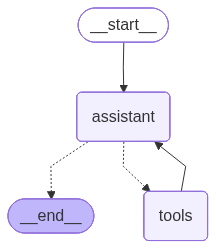

In [4]:
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display

def assistant(state: MessagesState):
    sys_msg = "You are a helpful assistant that can search the web to answer questions. Always cite your sources."
    return {"messages": llm_with_tools.invoke([SystemMessage(sys_msg)] + state["messages"])}

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
messages = [HumanMessage(content="What are the top 3 trending AI tools right now?")]
output = graph.invoke({"messages": messages})

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the top 3 trending AI tools right now?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_3z9YyzZYNWSeLJWnIOIPDETB)
 Call ID: call_3z9YyzZYNWSeLJWnIOIPDETB
  Args:
    query: top trending AI tools right now 2026 AI tool trends
  tavily_search_results_json (call_HKFNe6zo2SNZIkrPyZZlTch4)
 Call ID: call_HKFNe6zo2SNZIkrPyZZlTch4
  Args:
    query: most popular AI tools 2026 trend rankings ChatGPT Claude Gemini Perplexity Midjourney
  tavily_search_results_json (call_wrhtG5mQvPTHOcQBPVQpqUEV)
 Call ID: call_wrhtG5mQvPTHOcQBPVQpqUEV
  Args:
    query: current trending AI tools product hunt ai tools 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The best AI productivity tools in 2026 - Zapier", "url": "https://zapier.com/blog/best-ai-productiv

---
## Step 4: Adding Memory

Right now, each `invoke()` call starts fresh — the agent has no memory of previous conversations. Let's fix that.

<img src="./assets-resources/2025-02-10-16-25-13.png" width=50%>

### Key Concepts

- **Memory**: The ability to process, store, and recall information from past interactions
- **Persistence**: LangGraph saves snapshots of graph state using **checkpointers** at every superstep
- **Threads**: Individual sessions/conversations identified by a unique `thread_id`
- **Checkpoints**: Saved state snapshots that enable resumption, time-travel, and human-in-the-loop

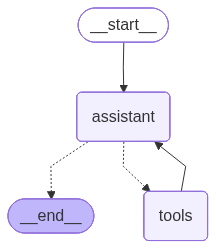

In [10]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.memory import MemorySaver

memory = InMemorySaver()
memory = MemorySaver()
# Re-compile the same graph, but now with a checkpointer
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

### Using Thread IDs

The `thread_id` in the config tells the checkpointer which conversation to load/save. Same thread = same conversation history.

In [11]:
config = {"configurable": {"thread_id": "chawabunga"}}

# First message in thread 1
messages = [HumanMessage(content="What is the weather in Tokyo?")]
output = graph.invoke({"messages": messages}, config)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the weather in Tokyo?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_AQ6guUqa0pSci1ElqlZFF127)
 Call ID: call_AQ6guUqa0pSci1ElqlZFF127
  Args:
    query: Tokyo weather current conditions forecast today official weather source
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Weather for Tokyo, Japan - Time and Date", "url": "https://www.timeanddate.com/weather/japan/tokyo", "content": "timeanddate.com\nFlag for Japan\n\n# Weather in Tokyo, Japan\n\nOvercast.\n\nFeels Like: 65 °F  \nForecast: 65 / 48 °F  \nWind: 16 mph ↑ from South\n\n|  |  |\n --- |\n| Location: | Tokyo |\n| Current Time: | Apr 7, 2026 at 12:13:34 am |\n| Latest Report: | Apr 6, 2026 at 9:00 pm |\n| Visibility: | 13 mi |\n| Pressure: | 29.85 \"Hg |\n| Humidity: | 66% |\n| Dew

In [12]:
# Follow-up in the SAME thread — the agent remembers!
new_message = HumanMessage(content="What was the city from the previous question?")
output = graph.invoke({"messages": [new_message]}, config)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the weather in Tokyo?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_AQ6guUqa0pSci1ElqlZFF127)
 Call ID: call_AQ6guUqa0pSci1ElqlZFF127
  Args:
    query: Tokyo weather current conditions forecast today official weather source
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Weather for Tokyo, Japan - Time and Date", "url": "https://www.timeanddate.com/weather/japan/tokyo", "content": "timeanddate.com\nFlag for Japan\n\n# Weather in Tokyo, Japan\n\nOvercast.\n\nFeels Like: 65 °F  \nForecast: 65 / 48 °F  \nWind: 16 mph ↑ from South\n\n|  |  |\n --- |\n| Location: | Tokyo |\n| Current Time: | Apr 7, 2026 at 12:13:34 am |\n| Latest Report: | Apr 6, 2026 at 9:00 pm |\n| Visibility: | 13 mi |\n| Pressure: | 29.85 \"Hg |\n| Humidity: | 66% |\n| Dew

In [9]:
# A DIFFERENT thread — isolated conversation, no memory of thread 1
config2 = {"configurable": {"thread_id": "2"}}

output = graph.invoke(
    {"messages": [HumanMessage(content="What was the city from the previous question?")]},
    config2
)

# The agent won't know — this is a fresh thread
for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What was the city from the previous question?
================================== Ai Message ==================================

I don’t have the previous question or its context in this chat, so I can’t tell which city you mean. If you paste the earlier question, I can identify the city.


---
## Summary

| What we built | Key API |
|---------------|--------|
| ReAct agent with web search | `ToolNode`, `tools_condition`, `TavilySearchResults` |
| Persistent memory | `MemorySaver`, `thread_id` in config |
| Isolated conversations | Different `thread_id` values |

**Next**: In Notebook 3, we'll build a RAG agent that retrieves from documents and can fall back to web search.